In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 데이터 로드
df = pd.read_csv("swing_dataset.csv")

# 피처 선택
features = [
    "max_hip", "avg_hip", "max_shoulder",
    "max_gap", "min_gap", "avg_gap",
    "avg_head_move", "avg_elbow_dist",
    "avg_knee_angle", "avg_wrist_y",
    "avg_hip_z", 
    # "max_sep_z", "avg_sep_z"
]

X = df[features]
y = df["label"]

# 교차검증
models = {
    "LightGBM":            LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost":             XGBClassifier(random_state=42, verbosity=0),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM":                 SVC(random_state=42),
}

print("=" * 50)
print("모델별 교차검증 결과 (5-Fold)")
print("=" * 50)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{name:25s}: {scores.mean():.3f} (+/- {scores.std():.3f})")

모델별 교차검증 결과 (5-Fold)
LightGBM                 : 0.529 (+/- 0.035)
XGBoost                  : 0.871 (+/- 0.079)
Random Forest            : 0.946 (+/- 0.066)
Logistic Regression      : 0.657 (+/- 0.065)
SVM                      : 0.632 (+/- 0.046)


In [2]:
# 전체 데이터로 최종 학습
final_model = RandomForestClassifier(random_state=42)
final_model.fit(X, y)

# 모델 저장
joblib.dump(final_model, "swing_model.pkl")
print("모델 저장 완료 → swing_model.pkl")

모델 저장 완료 → swing_model.pkl


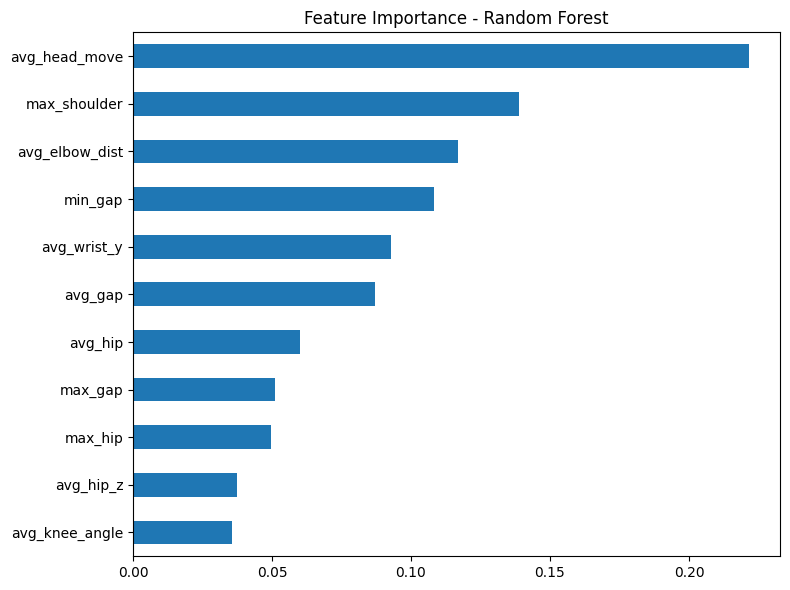

In [3]:
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()